In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mtcnn import MTCNN
import os
import cv2
import tqdm
import random
import pathlib
import collections
from IPython import display
from glob import glob

In [2]:
print("Number of GPUs : ",len(tf.config.experimental.list_physical_devices('GPU')))

Number of GPUs :  1


In [3]:
video_count_train = len(list(glob('train_sample_videos/*.mp4')))

print(f'Total number of videos in training set: {video_count_train}')

Total number of videos in training set: 400


In [4]:
import tensorflow as tf
import gc

# Clear Keras session and force garbage collection
tf.keras.backend.clear_session()
gc.collect()

0

# Data preprocessing

In [5]:
face_dir = 'C:\\Users\\admin\\Desktop\\Deep_learning\\Faces frames'
all_video_ids = [d for d in os.listdir(face_dir) if os.path.isdir(os.path.join(face_dir, d))]

In [6]:
random.seed(42) 
random.shuffle(all_video_ids)

In [7]:
split_index = int(0.8 * len(all_video_ids))
train_ids = all_video_ids[:split_index]
val_ids = all_video_ids[split_index:]

In [8]:
print(f"Training on {len(train_ids)} videos, Validating on {len(val_ids)} videos.")

Training on 320 videos, Validating on 80 videos.


In [9]:
def sequence_generator(video_id_list):
    face_dir = 'C:\\Users\\admin\\Desktop\\Deep_learning\\Faces frames'
    seq_length = 20
    img_size = (128, 128)  # Scaled down from 256
    
    for vid_id in video_id_list:
        folder_path = os.path.join(face_dir, vid_id)
        if not os.path.exists(folder_path): continue
            
        img_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])[:seq_length]
        if not img_names: continue
            
        frames = []
        for img_name in img_names:
            img_path = os.path.join(folder_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, img_size)
            img = tf.keras.applications.resnet50.preprocess_input(img)
            frames.append(img)
            
        # Pad shorter sequences
        while len(frames) < seq_length:
            frames.append(tf.zeros((img_size[0], img_size[1], 3)))
            
        # Dummy label (replace with your actual label logic if needed)
        label = np.random.randint(0, 2)
        yield tf.stack(frames), label

In [10]:
train_ds = tf.data.Dataset.from_generator(
    lambda: sequence_generator(train_ids),
    output_signature=(
        tf.TensorSpec(shape=(20, 128, 128, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
).shuffle(10).batch(2).prefetch(tf.data.AUTOTUNE)

In [11]:
val_ds = tf.data.Dataset.from_generator(
    lambda: sequence_generator(val_ids),
    output_signature=(
        tf.TensorSpec(shape=(20, 128, 128, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
).batch(2).prefetch(tf.data.AUTOTUNE)

In [12]:
# 1. Initialize the MTCNN detector
detector = MTCNN()

def process_all_videos(video_dir, output_dir, frames_to_sample=20, img_size=256):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Loop through all videos in your training set
    for video_name in os.listdir(video_dir):
        if not video_name.endswith(('.mp4', '.avi', '.mov')):
            continue
            
        video_path = os.path.join(video_dir, video_name)
        video_id = os.path.splitext(video_name)[0]
        video_output_path = os.path.join(output_dir, video_id)
        os.makedirs(video_output_path, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Calculate sampling interval to get uniform frames across the video
        interval = max(1, total_frames // frames_to_sample)
        
        frame_count = 0
        saved_count = 0

        while cap.isOpened() and saved_count < frames_to_sample:
            ret, frame = cap.read()
            if not ret:
                break

            # Process only frames at the calculated interval
            if frame_count % interval == 0:
                # MTCNN expects RGB images
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = detector.detect_faces(frame_rgb)

                if results:
                    # Get the face with the highest confidence
                    best_face = max(results, key=lambda x: x['confidence'])
                    x, y, width, height = best_face['box']
                    
                    # Fix potential negative coordinates from detector
                    x, y = max(0, x), max(0, y)
                    
                    # Crop and Resize
                    face_img = frame[y:y+height, x:x+width]
                    if face_img.size > 0:
                        face_resized = cv2.resize(face_img, (img_size, img_size))
                        
                        # Save the frame
                        save_name = f"frame_{saved_count:03d}.jpg"
                        cv2.imwrite(os.path.join(video_output_path, save_name), face_resized)
                        saved_count += 1
            
            frame_count += 1

        cap.release()
        print(f"Finished processing {video_name}: Saved {saved_count} frames.")

In [7]:
process_all_videos('C:\\Users\\admin\\Desktop\\Deep_learning\\train_sample_videos', 
                   'C:\\Users\\admin\\Desktop\\Deep_learning\\Faces frames')

Finished processing aagfhgtpmv.mp4: Saved 20 frames.
Finished processing aapnvogymq.mp4: Saved 20 frames.
Finished processing abarnvbtwb.mp4: Saved 20 frames.
Finished processing abofeumbvv.mp4: Saved 16 frames.
Finished processing abqwwspghj.mp4: Saved 20 frames.
Finished processing acifjvzvpm.mp4: Saved 20 frames.
Finished processing acqfdwsrhi.mp4: Saved 20 frames.
Finished processing acxnxvbsxk.mp4: Saved 20 frames.
Finished processing acxwigylke.mp4: Saved 20 frames.
Finished processing aczrgyricp.mp4: Saved 20 frames.
Finished processing adhsbajydo.mp4: Saved 14 frames.
Finished processing adohikbdaz.mp4: Saved 20 frames.
Finished processing adylbeequz.mp4: Saved 20 frames.
Finished processing aelfnikyqj.mp4: Saved 20 frames.
Finished processing aelzhcnwgf.mp4: Saved 20 frames.
Finished processing aettqgevhz.mp4: Saved 20 frames.
Finished processing aevrfsexku.mp4: Saved 20 frames.
Finished processing afoovlsmtx.mp4: Saved 20 frames.
Finished processing agdkmztvby.mp4: Saved 20 f

In [17]:
def build_final_model(seq_length=20):
    # 1. Augmentation Layer
    augmentation = models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
        layers.RandomWidth(0.2)
    ])

    # 2. Base CNN
    base_cnn = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, pooling='avg')
    base_cnn.trainable = False # Start frozen

    model = models.Sequential([
        layers.Input(shape=(seq_length, 128, 128, 3)),
        layers.TimeDistributed(augmentation),
        layers.TimeDistributed(base_cnn),
        layers.LSTM(128, dropout=0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    
    return model, base_cnn

In [18]:
model, base_cnn = build_final_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_4 (TimeDis  (None, 20, 128, 128, 3)  0         
 tributed)                                                       
                                                                 
 time_distributed_5 (TimeDis  (None, 20, 2048)         23587712  
 tributed)                                                       
                                                                 
 lstm_4 (LSTM)               (None, 128)               1114624   
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 2)                

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import datetime

# 1. Model Checkpoint: Saves the model only when validation loss improves
checkpoint_path = "best_deepfake_model.h5"
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [21]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [22]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

callbacks_list = [checkpoint, early_stopping, tensorboard_callback]

In [24]:
model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks_list)

Epoch 1/15
    159/Unknown - 250s 2s/step - loss: 0.7234 - accuracy: 0.5031
Epoch 1: val_loss did not improve from 0.67562
159/159 [==============================] - 262s 2s/step - loss: 0.7234 - accuracy: 0.5031 - val_loss: 0.7276 - val_accuracy: 0.4805
Epoch 2/15
159/159 [==============================] - ETA: 0s - loss: 0.7162 - accuracy: 0.4686
Epoch 2: val_loss did not improve from 0.67562
159/159 [==============================] - 240s 2s/step - loss: 0.7162 - accuracy: 0.4686 - val_loss: 0.7104 - val_accuracy: 0.4026
Epoch 3/15
159/159 [==============================] - ETA: 0s - loss: 0.7102 - accuracy: 0.5126
Epoch 3: val_loss did not improve from 0.67562
159/159 [==============================] - 272s 2s/step - loss: 0.7102 - accuracy: 0.5126 - val_loss: 0.6971 - val_accuracy: 0.5065
Epoch 4/15
159/159 [==============================] - ETA: 0s - loss: 0.7082 - accuracy: 0.4654
Epoch 4: val_loss did not improve from 0.67562
159/159 [==============================] - 310s 2s/s

In [25]:
# Unfreeze the last few layers of ResNet
base_cnn.trainable = True
for layer in base_cnn.layers[:-10]:
    layer.trainable = False

# Recompile with a VERY low learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks_list)

Epoch 1/10
    159/Unknown - 290s 2s/step - loss: 0.7065 - accuracy: 0.4969
Epoch 1: val_loss did not improve from 0.67562
159/159 [==============================] - 307s 2s/step - loss: 0.7065 - accuracy: 0.4969 - val_loss: 0.6932 - val_accuracy: 0.5584
Epoch 2/10
159/159 [==============================] - ETA: 0s - loss: 0.6985 - accuracy: 0.4937
Epoch 2: val_loss did not improve from 0.67562
159/159 [==============================] - 343s 2s/step - loss: 0.6985 - accuracy: 0.4937 - val_loss: 0.7166 - val_accuracy: 0.4026
Epoch 3/10
159/159 [==============================] - ETA: 0s - loss: 0.7032 - accuracy: 0.5094
Epoch 3: val_loss did not improve from 0.67562
159/159 [==============================] - 322s 2s/step - loss: 0.7032 - accuracy: 0.5094 - val_loss: 0.7022 - val_accuracy: 0.5325
Epoch 4/10
159/159 [==============================] - ETA: 0s - loss: 0.7050 - accuracy: 0.4906
Epoch 4: val_loss did not improve from 0.67562
159/159 [==============================] - 339s 2s/s

In [26]:
model = tf.keras.models.load_model('best_deepfake_model.h5')
detector = MTCNN()

In [27]:
def predict_video(video_path, seq_length=20):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = max(1, total_frames // seq_length)
    
    frames = []
    saved_count = 0
    
    while cap.isOpened() and len(frames) < seq_length:
        ret, frame = cap.read()
        if not ret: break
        
        # Process every Nth frame to match training sampling
        if saved_count % interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(frame_rgb)
            
            if results:
                best_face = max(results, key=lambda x: x['confidence'])
                x, y, w, h = best_face['box']
                x, y = max(0, x), max(0, y)
                
                # Crop and resize to 128x128 (matching our memory-optimized model)
                face = frame[y:y+h, x:x+w]
                face = cv2.resize(face, (128, 128))
                
                # ResNet50 Preprocessing
                face = tf.keras.applications.resnet50.preprocess_input(face)
                frames.append(face)
        
        saved_count += 1
    
    cap.release()

    # Padding if the video was too short
    while len(frames) < seq_length:
        frames.append(np.zeros((128, 128, 3)))

    # Convert to Batch format: (1, 20, 128, 128, 3)
    input_tensor = np.expand_dims(np.array(frames), axis=0)
    
    # 2. Make Prediction
    prediction = model.predict(input_tensor)
    
    # Get index of highest probability (0: Real, 1: Fake)
    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]
    
    label = "FAKE" if class_idx == 1 else "REAL"
    return label, confidence

In [28]:
result, score = predict_video('C:\\Users\\admin\\Desktop\\Deep_learning\\test_videos\\test_videos\\cqxxumarvp.mp4')

1/1 [==============================] - 3s 3s/step


In [29]:
print(f"Prediction: {result} ({score*100:.2f}%)")

Prediction: FAKE (52.97%)


In [30]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [31]:
# Collect all true labels and predictions
y_true = []
y_pred = []

print("Generating predictions for validation set...")
for x, y in val_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

Generating predictions for validation set...



Classification Report:
              precision    recall  f1-score   support

        REAL       0.43      0.56      0.49        36
        FAKE       0.48      0.37      0.42        41

    accuracy                           0.45        77
   macro avg       0.46      0.46      0.45        77
weighted avg       0.46      0.45      0.45        77



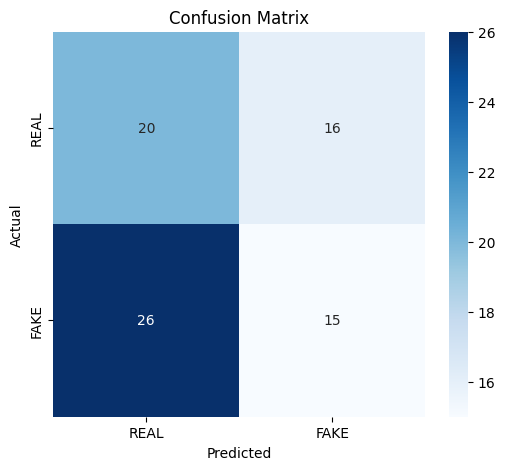

In [32]:
def plot_evaluation(y_true, y_pred):
    # 1. Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['REAL', 'FAKE']))

    # 2. Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['REAL', 'FAKE'], 
                yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

plot_evaluation(y_true, y_pred)

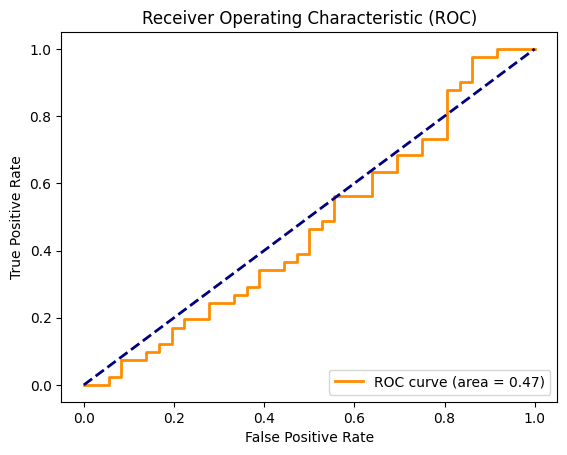

In [33]:
# Note: For ROC, we need the raw probabilities for the 'FAKE' class (index 1)
y_probs = []
for x, y in val_ds:
    preds = model.predict(x, verbose=0)
    y_probs.extend(preds[:, 1])

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

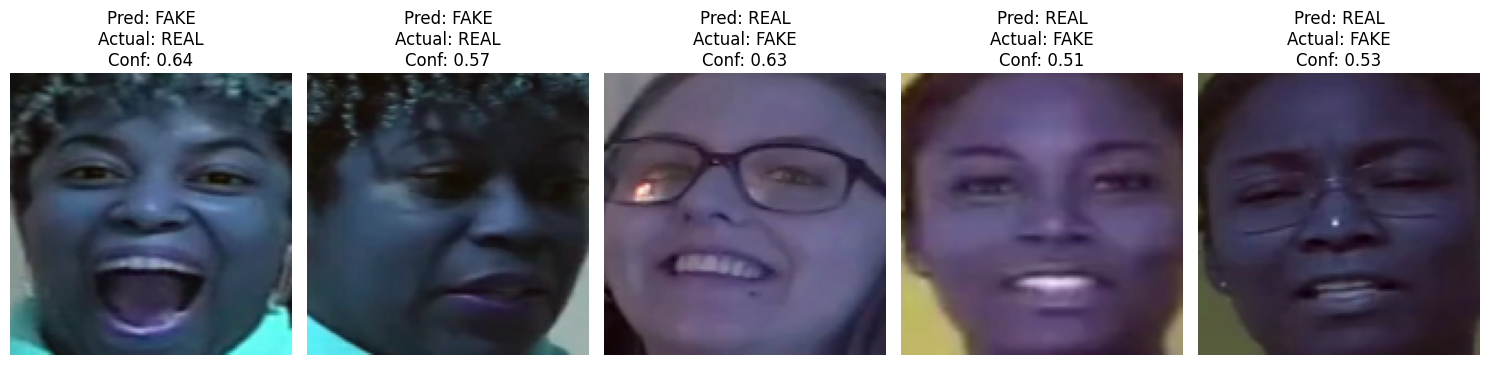

In [34]:
def visualize_errors(dataset, model, num_examples=5):
    error_frames = []
    error_details = []

    for x_batch, y_batch in dataset:
        preds = model.predict(x_batch, verbose=0)
        for i in range(len(x_batch)):
            predicted_class = np.argmax(preds[i])
            actual_class = y_batch[i].numpy()
            
            if predicted_class != actual_class:
                # Store the first frame of the sequence for visualization
                # We reverse the ResNet preprocessing to make it viewable
                first_frame = x_batch[i][0].numpy()
                # Simple de-normalization for visualization
                first_frame = (first_frame - first_frame.min()) / (first_frame.max() - first_frame.min())
                
                error_frames.append(first_frame)
                error_details.append({
                    'pred': 'FAKE' if predicted_class == 1 else 'REAL',
                    'actual': 'FAKE' if actual_class == 1 else 'REAL',
                    'conf': preds[i][predicted_class]
                })
            
            if len(error_frames) >= num_examples:
                break
        if len(error_frames) >= num_examples:
            break

    # Plotting the errors
    plt.figure(figsize=(15, 5))
    for i in range(len(error_frames)):
        plt.subplot(1, num_examples, i + 1)
        plt.imshow(error_frames[i])
        plt.title(f"Pred: {error_details[i]['pred']}\nActual: {error_details[i]['actual']}\nConf: {error_details[i]['conf']:.2f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_errors(val_ds, model)